### Investigating YOLO Detections

In [1]:
from src.components.person_detector import PersonDetector
from src.components.quality_filter import QualityFilter

from src.constants import IMAGES_DIR
from src.logger.custom_logger import logger,configure_logger

from src.settings.config import PersonDetectionThresholds,QualityThresholds
from src.utils.io import ImageLoader

22:31:08 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-09\22-31-08.log


In [2]:
configure_logger(log_level="WARNING")

WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-09/22-31-08.log')

### Load the quality check filter and YOLO detector

In [3]:
quality_thresholds = QualityThresholds()
detection_thresholds = PersonDetectionThresholds()

quality_filter = QualityFilter(quality_thresholds)
detector = PersonDetector(detection_thresholds)
loader = ImageLoader()

### Remove Duplicate images

In [4]:
import hashlib 
from pathlib import Path

def file_hash(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()
# hashlib.md5 converts bytes to fixed hash
# hexdigest converts into readable text 

all_paths = sorted(IMAGES_DIR.glob("*.png"))
seen_hashes: set[str] = set()
unique_paths: list[Path] = []

for p in all_paths:
    h = file_hash(p)
    if h in seen_hashes:
        continue 
    seen_hashes.add(h)
    unique_paths.append(p)

print(f"Total images: {len(all_paths)}\nTotal unique images (no duplicates): {len(unique_paths)}")

Total images: 1147
Total unique images (no duplicates): 1001


### Performing quality checks and inferencing with YOLO 

In [5]:
import numpy as np 
import pandas as pd 

records: list[dict] = []

for path in unique_paths:
    crop =  loader.load(path)

    quality_result = quality_filter.apply(crop)
    if not quality_result.passed:
        records.append({"crop_id":crop.crop_id,
                        "source_path":str(path),
                        "quality_passed":False,
                        "detection_passed":None,
                        "n_detections_raw":np.nan,
                        "top_confidence":np.nan,
                        "top_bbox_area_ratio":np.nan,
                        "detection_reason":None})
        continue 

    detection_result = detector.apply(crop)
    records.append({"crop_id":crop.crop_id,
                    "source_path":str(path),
                    "quality_passed":True,
                    "detection_passed":detection_result.passed if detection_result else None,
                    "n_detections_raw":detection_result.metrics.get("n_detections_raw") if detection_result else np.nan,
                    "top_confidence":detection_result.metrics.get("top_confidence") if detection_result else np.nan,
                    "top_bbox_area_ratio":detection_result.metrics.get("top_bbox_area_ratio") if detection_result else np.nan,
                    "detection_reason":detection_result.reason if detection_result else None})

df = pd.DataFrame.from_records(records)
print(f"No of rows: {len(df)}")
print(f"shape of df: {df.shape}")
df.head()

No of rows: 1001
shape of df: (1001, 8)


,crop_id,source_path,quality_passed,detection_passed,n_detections_raw,top_confidence,top_bbox_area_ratio,detection_reason
0,crop (1),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,True,True,1.0,0.520359,0.867005,ok
1,crop (10),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,False,None,NaN,NaN,NaN,None
2,crop (100),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,True,False,0.0,0.000000,0.000000,no_person_detected
3,crop (1000),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,True,True,3.0,0.784797,0.810817,ok
4,crop (1001),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,True,False,0.0,0.000000,0.000000,no_person_detected


In [6]:
print("--- Stage 0 ---")
print(df["quality_passed"].value_counts())
print()
print("--- Stage 1 (on quality-survivors) ---")
survivors = df[df["quality_passed"]].copy()
print(survivors["detection_passed"].value_counts())
print()
print("--- Stage 1 rejection reasons ---")
print(
    survivors[survivors["detection_passed"] == False]
    ["detection_reason"]
    .value_counts()
)

--- Stage 0 ---
quality_passed
True     784
False    217
Name: count, dtype: int64

--- Stage 1 (on quality-survivors) ---
detection_passed
True     461
False    323
Name: count, dtype: int64

--- Stage 1 rejection reasons ---
detection_reason
no_person_detected        318
top_bbox_area=0.09<0.4      1
top_bbox_area=0.37<0.4      1
top_bbox_area=0.38<0.4      1
top_bbox_area=0.06<0.4      1
top_bbox_area=0.13<0.4      1
Name: count, dtype: int64


Bucket A — 'YOLO saw nothing': 318 crops


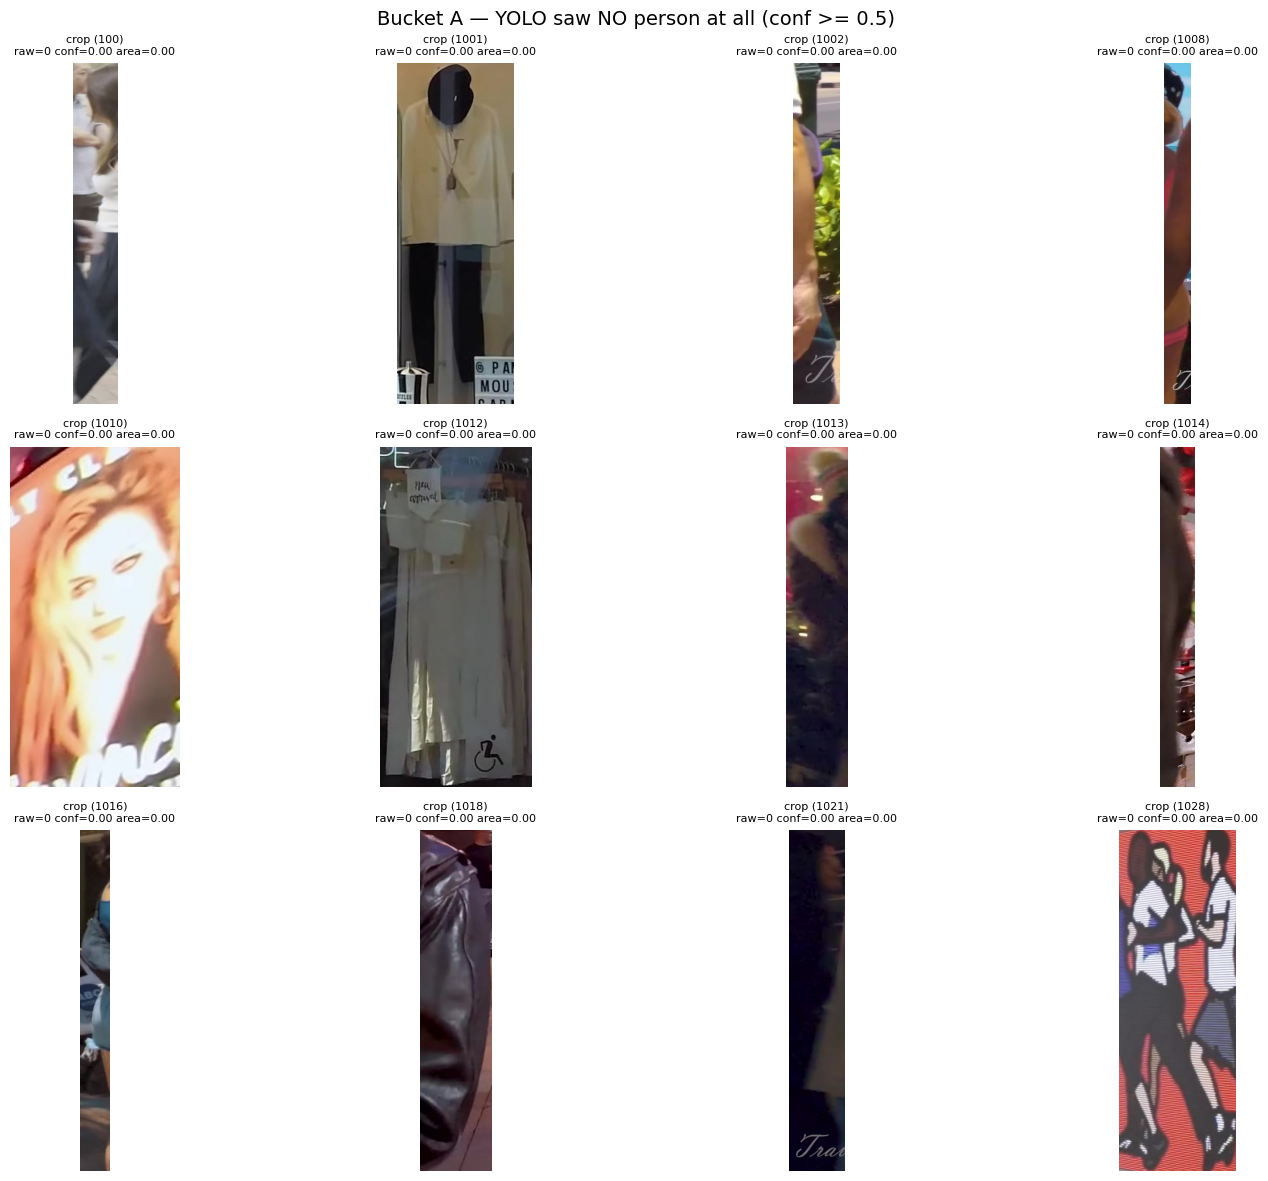


Bucket B — 'YOLO saw a person, but too small': 5 crops


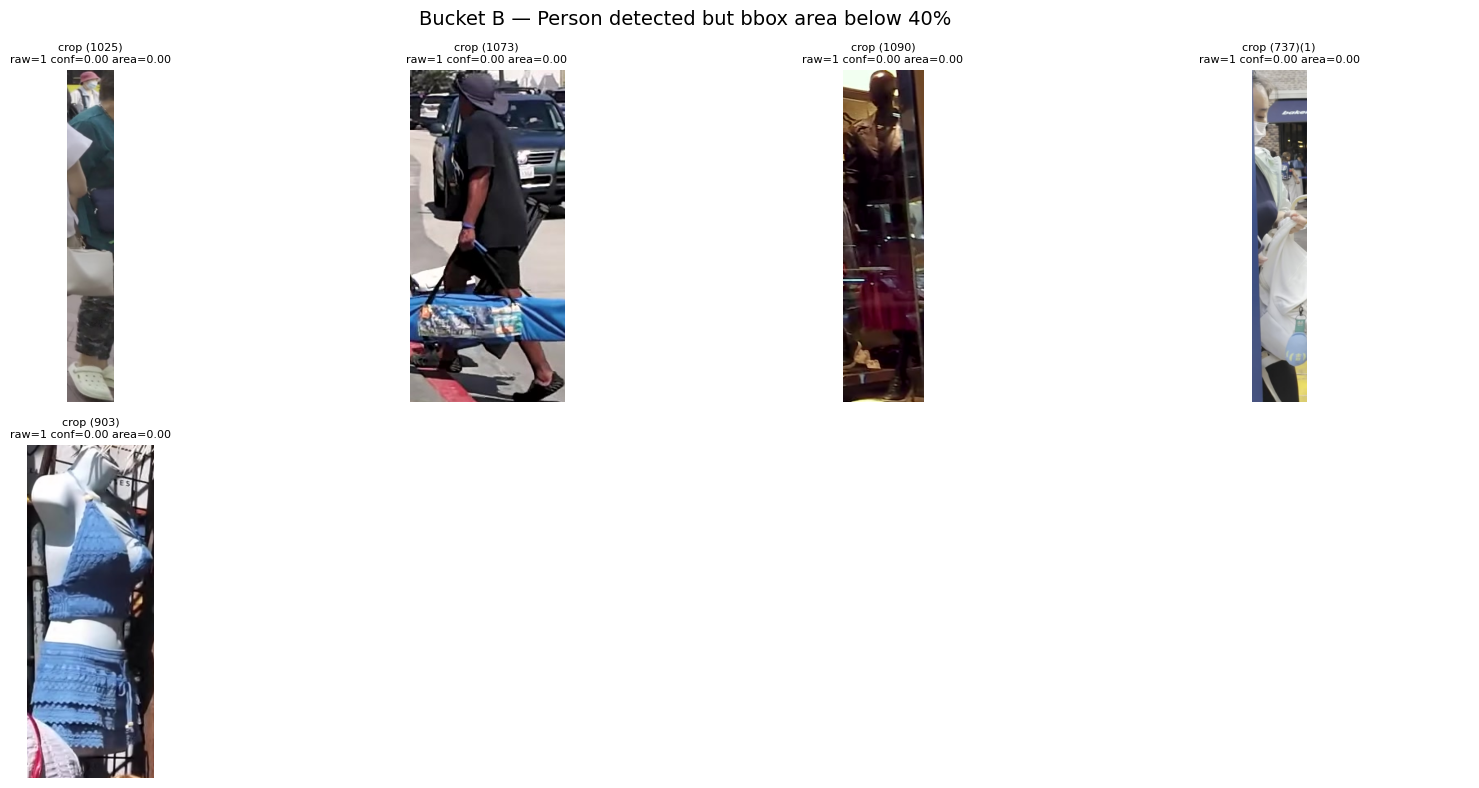

In [8]:
import matplotlib.pyplot as plt 

def show_grid(crops_df: pd.DataFrame, title: str, n: int = 12) -> None:
    sample = crops_df.head(n)
    n_rows = (len(sample) + 3) // 4
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
    axes = np.atleast_2d(axes).flatten()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        crop = loader.load(Path(row["source_path"]))
        ax.imshow(crop.image)
        ax.set_title(
            f"{row['crop_id'][:20]}\n"
            f"raw={int(row['n_detections_raw'])} "
            f"conf={row['top_confidence']:.2f} "
            f"area={row['top_bbox_area_ratio']:.2f}",
            fontsize=8,
        )
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# Bucket 1: YOLO saw NOTHING at conf=0.5
no_detection = survivors[
    (survivors["detection_passed"] == False) & (survivors["n_detections_raw"] == 0)
]
print(f"Bucket A — 'YOLO saw nothing': {len(no_detection)} crops")
show_grid(no_detection, "Bucket A — YOLO saw NO person at all (conf >= 0.5)")

# Bucket 2: YOLO saw a person but the bbox was too small
small_bbox = survivors[
    (survivors["detection_passed"] == False) & (survivors["n_detections_raw"] > 0)
]
print(f"\nBucket B — 'YOLO saw a person, but too small': {len(small_bbox)} crops")
show_grid(small_bbox, "Bucket B — Person detected but bbox area below 40%")

### Bucket A
- Consists of images of advertisements.
- Some images contain human but very much cropped out.


### Bucket B
- Some manequins were detected 
- Humans were also detected but image was very much cropped out